<a href="https://colab.research.google.com/github/jsalafica/Data-Science-III/blob/master/Entrega_Final_DSIII_Javier_Salafica2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Entrega Final — NLP + Deep Learning (Clasificación de texto clínico)

**Objetivo:** construir un pipeline de NLP en español para clasificar textos clínicos simples en un único servicio médico (single-label), aplicando preprocesamiento y entrenando:
1) un modelo clásico (Regresión Logística)
2) una red neuronal simple (Deep Learning) con Keras

**Dataset:** CSV con ≥1000 filas, cargado desde GitHub.


In [1]:
!pip -q install spacy
!python -m spacy download es_core_news_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 67.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [32]:
!pip -q install wordcloud
from wordcloud import WordCloud

In [2]:
import re
import numpy as np
import pandas as pd

import spacy
from spacy.lang.es.stop_words import STOP_WORDS

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from tensorflow import keras
from tensorflow.keras import layers


## 1. Carga del dataset

Se carga el dataset desde GitHub (formato CSV, separador `;`).  
El dataset contiene las columnas:

- `texto`: texto clínico en español  
- `servicio`: etiqueta (single-label)


In [3]:
URL = "https://raw.githubusercontent.com/jsalafica/Data-Science-III/refs/heads/master/dataset_nlp_1200.csv"

df = pd.read_csv(URL, sep=";")

print(df.shape)
df.head()

(1200, 2)


,texto,servicio
0,"Mujer 50 años con melena y mareos. Palidez, TA...",Gastroenterologia
1,"Paciente Mujer 76 años con otalgia, fiebre 38....",Otorrinolaringologia
2,"Paciente Mujer 19 años con cefalea intensa, fo...",Neurologia
3,"Mujer 35 años con ictericia, coluria y prurito...",Gastroenterologia
4,Niño 4 años con dolor abdominal y fiebre 37.7°...,Pediatria


In [4]:
print(df.columns)
print(df["servicio"].value_counts().head(10))
print("N clases:", df["servicio"].nunique())
print("N nulos texto:", df["texto"].isna().sum())
print("N nulos servicio:", df["servicio"].isna().sum())


Index(['texto', 'servicio'], dtype='object')
servicio
Gastroenterologia       75
Otorrinolaringologia    75
Neurologia              75
Pediatria               75
Cardiologia             75
UTI Adultos             75
Urologia                75
Neonatologia            75
Clinica Medica          75
UTI Pediatrica          75
Name: count, dtype: int64
N clases: 16
N nulos texto: 0
N nulos servicio: 0


## 2. Preprocesamiento NLP

Se aplica preprocesamiento con **spaCy**:

- Normalización (minúsculas y limpieza básica)
- Tokenización y lematización
- Eliminación de stopwords
- Preservación de información etaria mediante tokens semánticos:
  - `edad_adulto`
  - `edad_pediatrico`
  - `edad_neonatal`


In [5]:
nlp = spacy.load("es_core_news_sm")
stop_es = set(STOP_WORDS)

len(stop_es)


521

In [19]:
def preprocess_spacy(texto: str) -> str:
    texto = str(texto).lower()
    texto = re.sub(r"\s+", " ", texto).strip()

    # ---- Preservación etaria CORRECTA ----
    pat_edad = re.compile(r"\b(\d{1,3})\s*(años?|mes(?:es)?|d[ií]as?|horas?)\b", flags=re.IGNORECASE)

    def _edad_a_dias(valor: int, unidad: str) -> int:
        unidad = unidad.lower()
        if unidad.startswith("año"):
            return int(valor * 365)
        if unidad.startswith("mes"):
            return int(valor * 30)
        if unidad.startswith("día") or unidad.startswith("dia"):
            return int(valor)
        if unidad.startswith("hora"):
            return 0
        return None

    def _clasificar_edad_por_dias(dias: int) -> str:
        if dias is not None and dias < 30:
            return "edad_neonatal"
        if dias is not None and dias < (16 * 365):
            return "edad_pediatrico"
        return "edad_adulto"

    def _reemplazar_edad(match):
        valor = int(match.group(1))
        unidad = match.group(2)
        dias = _edad_a_dias(valor, unidad)
        token = _clasificar_edad_por_dias(dias)
        return f" {token} "

    texto = pat_edad.sub(_reemplazar_edad, texto)

    # ---- spaCy ----
    doc = nlp(texto)

    tokens = []
    for tok in doc:
        if tok.is_space or tok.is_punct:
            continue

        lemma = tok.lemma_.strip()
        if not lemma:
            continue

        # eliminar números puros (edad ya fue tokenizada)
        if lemma.isdigit():
            continue

        if lemma in stop_es:
            continue

        tokens.append(lemma)

    return " ".join(tokens)


In [20]:
df["texto_proc"] = df["texto"].astype(str).apply(preprocess_spacy)

df[["texto", "texto_proc"]].head(10)


,texto,texto_proc
0,"Mujer 50 años con melena y mareos. Palidez, TA...",mujer edad_adulto melena mareo palidez ta 139/...
1,"Paciente Mujer 76 años con otalgia, fiebre 38....",paciente mujer edad_adulto otalgia fiebre 38.2...
2,"Paciente Mujer 19 años con cefalea intensa, fo...",paciente mujer edad_adulto cefalea intenso fot...
3,"Mujer 35 años con ictericia, coluria y prurito...",mujer edad_adulto ictericia colurio prurito do...
4,Niño 4 años con dolor abdominal y fiebre 37.7°...,niño edad_pediatrico dolor abdominal fiebre 37...
5,"Mujer 32 años con palpitaciones, mareos y sens...",mujer edad_adulto palpitación mareo sensación ...
6,Varón 76 años con sepsis probable: fiebre 39.1...,varón edad_adulto sepsis probable fiebre 39.1 ...
7,"Varón 77 años con parestesias en mano, pérdida...",varón edad_adulto parestesia mano pérdida fuer...
8,"Mujer 76 años con melena y mareos. Palidez, TA...",mujer edad_adulto melena mareo palidez ta 133/...
9,Mujer 45 años con dolor en flanco irradiado a ...,mujer edad_adulto dolor flanco irradiado ingle...


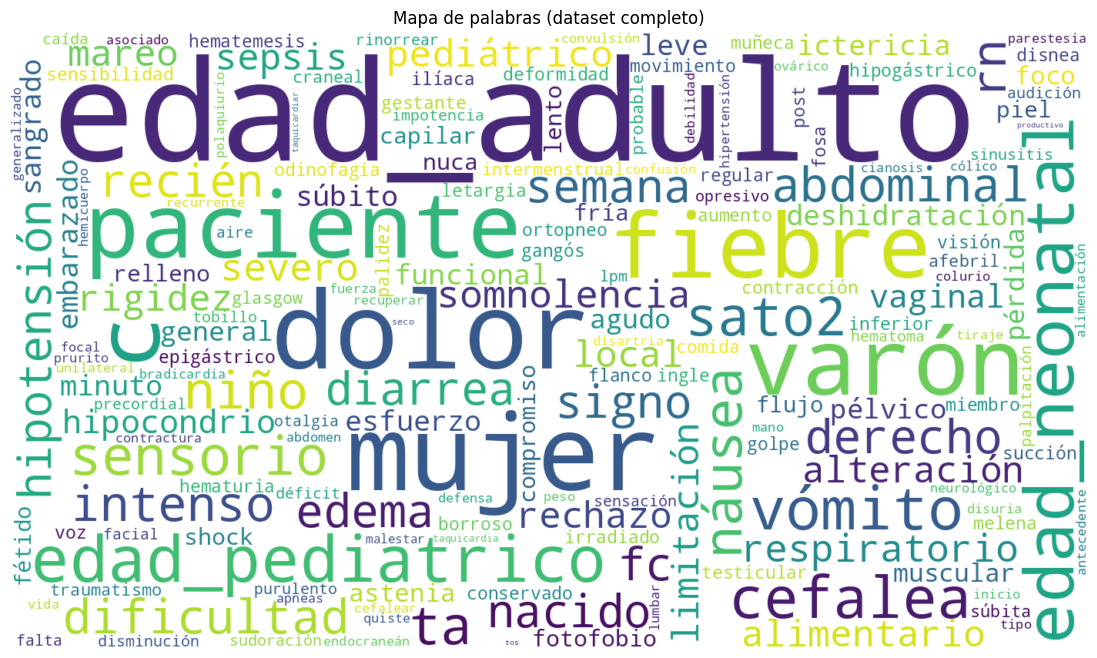

In [33]:
texto_total = " ".join(df["texto_proc"].dropna().astype(str).tolist())

wc = WordCloud(
    width=1400,
    height=800,
    background_color="white",
    collocations=False  # evita juntar bigramas raros
).generate(texto_total)

plt.figure(figsize=(14, 8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Mapa de palabras (dataset completo)")
plt.show()


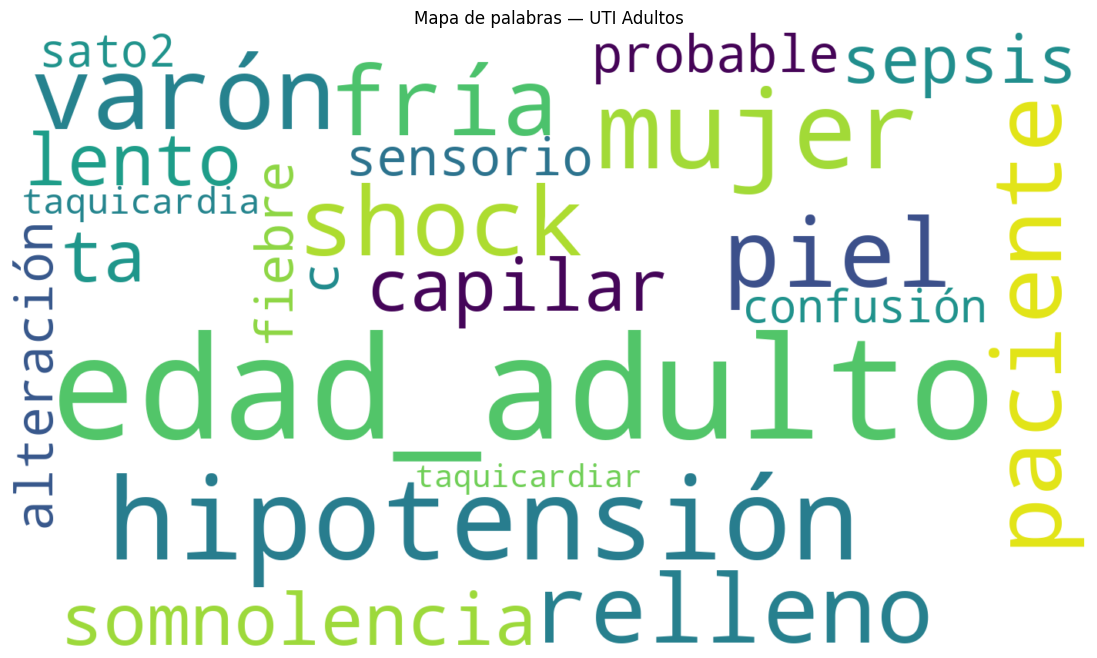

In [34]:
def wordcloud_por_servicio(servicio, max_words=200):
    subset = df.loc[df["servicio"] == servicio, "texto_proc"].dropna().astype(str)
    texto = " ".join(subset.tolist())

    wc = WordCloud(
        width=1400,
        height=800,
        background_color="white",
        max_words=max_words,
        collocations=False
    ).generate(texto)

    plt.figure(figsize=(14, 8))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Mapa de palabras — {servicio}")
    plt.show()

# Ejemplo:
wordcloud_por_servicio("UTI Adultos")


## 3. Vectorización (TF-IDF)

Transformamos el texto preprocesado a una matriz numérica usando TF-IDF.
Se utilizan unigramas y bigramas.


In [21]:
vectorizer = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=8000
)

X = vectorizer.fit_transform(df["texto_proc"])
y = df["servicio"]

print("X shape:", X.shape)
print("Clases:", y.nunique())


X shape: (1200, 929)
Clases: 16


## 4. Modelo clásico (Regresión Logística)

Se entrena un modelo base de clasificación multiclase usando Regresión Logística.
Se divide el dataset en train/test 80/20 con estratificación por clase.


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 1.0
                      precision    recall  f1-score   support

         Cardiologia       1.00      1.00      1.00        15
     Cirugia General       1.00      1.00      1.00        15
      Clinica Medica       1.00      1.00      1.00        15
   Gastroenterologia       1.00      1.00      1.00        15
         Ginecologia       1.00      1.00      1.00        15
        Neonatologia       1.00      1.00      1.00        15
        Neurocirugia       1.00      1.00      1.00        15
          Neurologia       1.00      1.00      1.00        15
         Obstetricia       1.00      1.00      1.00        15
Otorrinolaringologia       1.00      1.00      1.00        15
           Pediatria       1.00      1.00      1.00        15
       Traumatologia       1.00      1.00      1.00        15
         UTI Adultos       1.00      1.00      1.00        15
        UTI Neonatal       1.00      1.00      1.00        15
      UTI Pediatrica       1.00      1.00      1.00    

## 5. Análisis de resultados (Profundización NLP)

Se analiza la matriz de confusión para observar clases que se confunden entre sí.


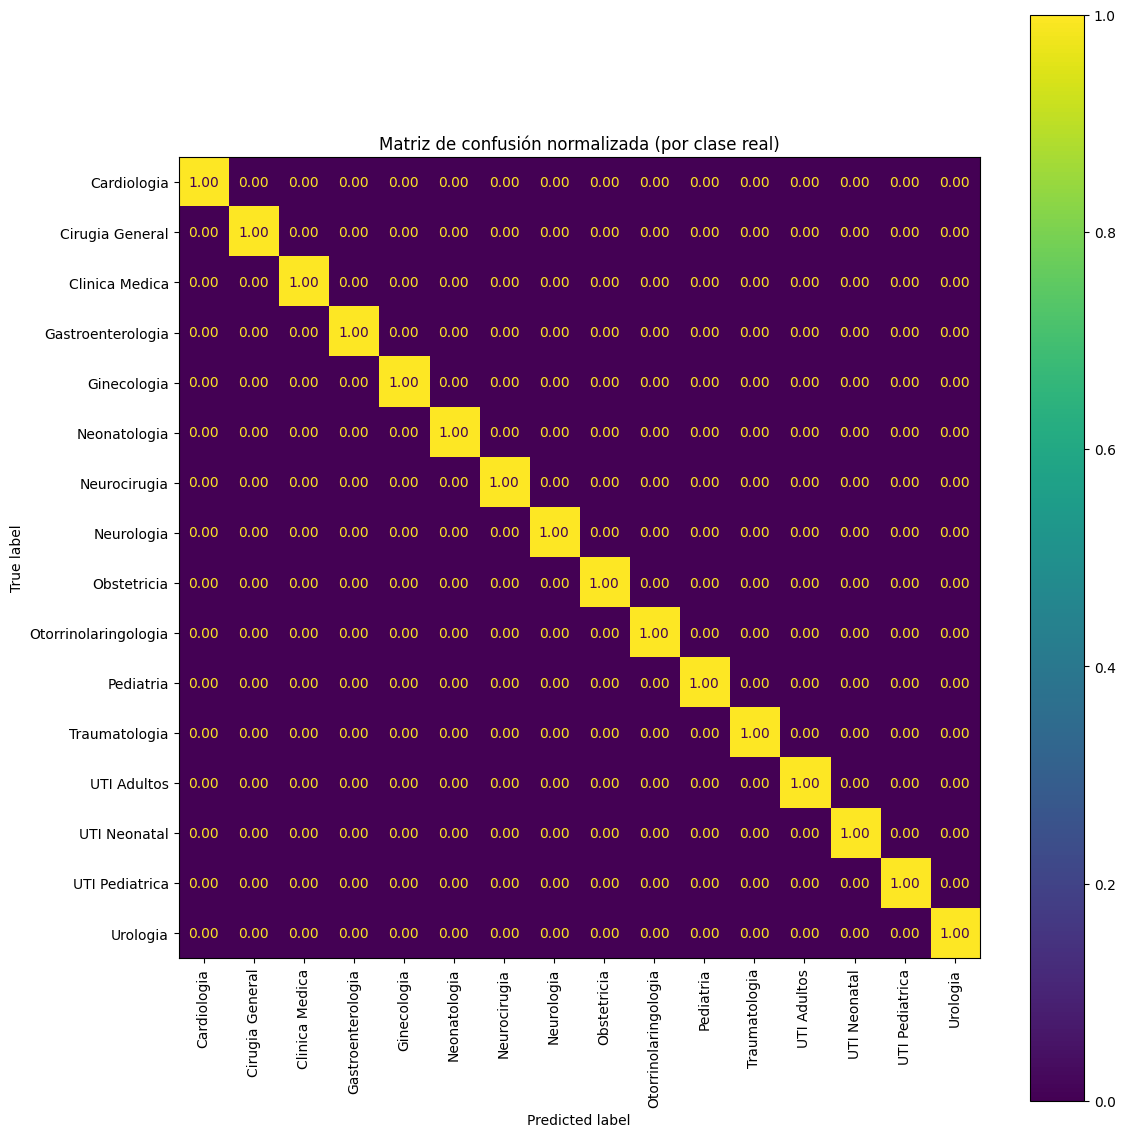

In [23]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels, normalize="true")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(ax=ax, xticks_rotation=90, values_format=".2f", colorbar=True)
plt.title("Matriz de confusión normalizada (por clase real)")
plt.tight_layout()
plt.show()


In [24]:
cm_raw = confusion_matrix(y_test, y_pred, labels=labels)
cm_df = pd.DataFrame(cm_raw, index=labels, columns=labels)

cm_err = cm_df.copy()
np.fill_diagonal(cm_err.values, 0)

top = cm_err.stack().sort_values(ascending=False).head(15)

print("Top 15 confusiones (Real -> Predicho : cantidad):")
for (real, pred), cnt in top.items():
    if cnt > 0:
        print(f"{real} -> {pred}: {cnt}")


Top 15 confusiones (Real -> Predicho : cantidad):


## 6. Interpretabilidad del modelo

La Regresión Logística permite inspeccionar los términos con mayor peso por clase.
Además, se muestra una explicación simple de una predicción individual.


In [25]:
feature_names = np.array(vectorizer.get_feature_names_out())
classes = model.classes_
coef = model.coef_

def top_terms_for_class(class_idx, top_n=12):
    top_pos_idx = np.argsort(coef[class_idx])[-top_n:][::-1]
    return list(zip(feature_names[top_pos_idx], coef[class_idx][top_pos_idx]))

for i, cls in enumerate(classes):
    tops = top_terms_for_class(i, top_n=10)
    print(f"\n=== {cls} | Top términos ===")
    for term, w in tops:
        print(f"{term:25s} {w:.3f}")



=== Cardiologia | Top términos ===
sudoración                1.303
sudoración náusea         1.303
opresivo minuto           1.303
precordial                1.303
minuto sudoración         1.303
opresivo                  1.303
precordial opresivo       1.303
dolor precordial          1.303
disnea esfuerzo           1.148
disnea                    1.148

=== Cirugia General | Top términos ===
derecho                   1.863
derecho post              1.318
comida fiebre             1.318
comida                    1.318
post                      1.318
post comida               1.318
fosa                      1.241
fosa ilíaca               1.241
derecho náusea            1.241
náusea fiebre             1.241

=== Clinica Medica | Top términos ===
dolor muscular            1.440
cefalea dolor             1.440
astenia cefalea           1.440
edad_adulto astenia       1.440
astenia                   1.440
muscular fiebre           1.440
muscular                  1.440
foco                 

In [26]:
def explain_prediction(texto_original, top_k=12):
    texto_p = preprocess_spacy(texto_original)
    X_one = vectorizer.transform([texto_p])

    scores = model.decision_function(X_one).ravel()
    pred_idx = np.argmax(scores)
    pred_class = model.classes_[pred_idx]

    row = X_one.tocoo()
    contrib = {}
    for j, v in zip(row.col, row.data):
        contrib[j] = contrib.get(j, 0.0) + (coef[pred_idx, j] * v)

    top = sorted(contrib.items(), key=lambda kv: kv[1], reverse=True)[:top_k]
    top_terms = [(feature_names[j], float(val)) for j, val in top]

    return {"texto_proc": texto_p, "prediccion": pred_class, "top_terms": top_terms}

ejemplo = "Niño 3 años con dificultad respiratoria severa, tiraje y saturación baja."
info = explain_prediction(ejemplo, top_k=12)

print("Texto procesado:", info["texto_proc"])
print("Predicción:", info["prediccion"])
print("Top términos que empujaron la predicción:")
for t, v in info["top_terms"]:
    print(f"{t:25s} {v:.4f}")


Texto procesado: niño edad_pediatrico dificultad respiratorio severo tiraje saturación
Predicción: UTI Pediatrica
Top términos que empujaron la predicción:
edad_pediatrico dificultad 0.5585
edad_pediatrico           0.5208
niño                      0.4321
niño edad_pediatrico      0.4321
dificultad respiratorio   0.3256
respiratorio              0.3256
respiratorio severo       0.3256
severo                    0.3256
dificultad                0.2613
tiraje                    -0.0375


## 7. Deep Learning (Red neuronal simple)

Se entrena una red neuronal feed-forward sencilla usando como entrada la matriz TF-IDF.


In [27]:
le = LabelEncoder()
y_enc = le.fit_transform(y)
num_classes = len(le.classes_)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

X_train_d = X_train.toarray()
X_test_d  = X_test.toarray()

y_train_oh = keras.utils.to_categorical(y_train, num_classes=num_classes)
y_test_oh  = keras.utils.to_categorical(y_test,  num_classes=num_classes)

X_train_d.shape, y_train_oh.shape, num_classes


((960, 929), (960, 16), 16)

In [28]:
input_dim = X_train_d.shape[1]

model_nn = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

model_nn.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_nn.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 128)            │       119,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │         2,064 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,104 (473.06 KB)

 Trainable params: 121,104 (473.06 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
early = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model_nn.fit(
    X_train_d, y_train_oh,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    callbacks=[early],
    verbose=1
)


Epoch 1/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.3615 - loss: 2.7155 - val_accuracy: 0.9740 - val_loss: 2.5122
Epoch 2/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9920 - loss: 2.4163 - val_accuracy: 1.0000 - val_loss: 2.1045
Epoch 3/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9990 - loss: 1.9496 - val_accuracy: 1.0000 - val_loss: 1.4956
Epoch 4/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 1.2947 - val_accuracy: 1.0000 - val_loss: 0.8539
Epoch 5/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.7072 - val_accuracy: 1.0000 - val_loss: 0.4337
Epoch 6/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.3609 - val_accuracy: 1.0000 - val_loss: 0.2311
Epoch 7/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.1950 - val_accuracy: 1.0000 - val_loss: 0.1405
Epoch 8/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.1212 - val_accuracy: 1.0000 - val_loss

In [30]:
y_pred_prob = model_nn.predict(X_test_d)
y_pred = np.argmax(y_pred_prob, axis=1)

print("Accuracy DL:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Accuracy DL: 1.0
                      precision    recall  f1-score   support

         Cardiologia       1.00      1.00      1.00        15
     Cirugia General       1.00      1.00      1.00        15
      Clinica Medica       1.00      1.00      1.00        15
   Gastroenterologia       1.00      1.00      1.00        15
         Ginecologia       1.00      1.00      1.00        15
        Neonatologia       1.00      1.00      1.00        15
        Neurocirugia       1.00      1.00      1.00        15
          Neurologia       1.00      1.00      1.00        15
         Obstetricia       1.00      1.00      1.00        15
Otorrinolaringologia       1.00      1.00      1.00        15
           Pediatria       1.00      1.00      1.00        15
       Traumatologia       1.00      1.00      1.00        15
         UTI Adultos       1.00      1.00      1.00        15
        UTI Neonatal       1.00      1.00      1.00        15
      UTI Pedi

In [31]:
def predict_nn(texto: str, top_k=5):
    t = preprocess_spacy(texto)
    v = vectorizer.transform([t]).toarray()
    p = model_nn.predict(v)[0]
    idx = np.argsort(p)[::-1][:top_k]
    return [(le.classes_[i], float(p[i])) for i in idx]

predict_nn("Varón 60 años con dolor precordial opresivo y sudoración.", top_k=5)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


[('Cardiologia', 0.9322972893714905),
 ('Neurocirugia', 0.009276729077100754),
 ('Ginecologia', 0.006968766450881958),
 ('Urologia', 0.006070295348763466),
 ('UTI Neonatal', 0.005299449898302555)]

## 8. Conclusiones

- Se construyó un pipeline de NLP en español con spaCy (tokenización, lematización, stopwords) y preservación de edad mediante tokens semánticos.
- Se vectorizó el texto con TF-IDF y se entrenó un modelo clásico (Regresión Logística) con evaluación mediante accuracy, reporte de clasificación y matriz de confusión.
- Se implementó una red neuronal simple (Deep Learning) usando Keras, cumpliendo el requisito mínimo solicitado.

**Trabajo futuro:** evaluar arquitecturas más potentes (Embeddings + LSTM/Transformers) y ampliar variabilidad de textos.
